In [12]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [13]:
tcga_samples = pd.read_csv('../code/samples.tsv', sep='\t')

/tmp/ipykernel_810149/3820792931.py:1: DtypeWarning: Columns (6,20,85,89,112,113,114,115,116,117,120,121,122,123,124,125,127,130,191,193,194,199,203,204,207,230,238,256,265,266,267,268,269,270,271,272,276,277,278,281,283,286,287,288,289,290,291,292,293,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,313,314,316,317,318,323,326,328,330,331,332,333,336,339,341,342,343,344,347,349,350,351,352,355,356,358,359,360,361,362,363,364,366,367,368,369,370,374,375,377,378,379,380,381,382,390,391,392,393,394,395,396,397,398,400,401,402,403,404,405,406,407,408,409,410,413,415,416,417,418,419,420,426,429,430,431,433,434,435,436,437,438,439,440,441,442,443,446,448,450,451,452,453,454,455,456,457,458,459,460,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,502,503,504,505,506,507,508,509,510,511,512,513,514,515,517,518,519,520,521,522,523,524,525,527,528,531,532,533,534,535,536,537,540

In [3]:
tcga_samples.columns[:15]#['gdc_cases.project.name'].unique()

Index(['rail_id', 'external_id', 'study', 'tcga_barcode', 'gdc_file_id',
       'gdc_cases.project.name', 'gdc_cases.project.released',
       'gdc_cases.project.state', 'gdc_cases.project.primary_site',
       'gdc_cases.project.project_id', 'cgc_sample_sample_type',
       'gdc_cases.case_id', 'gdc_updated_datetime', 'gdc_file_name',
       'gdc_submitter_id'],
      dtype='object')

In [6]:
tcga_samples.cgc_sample_sample_type.unique()

array(['Primary Tumor', 'Solid Tissue Normal', 'Metastatic', nan,
       'Recurrent Tumor', 'Additional - New Primary',
       'Primary Blood Derived Cancer - Peripheral Blood',
       'Additional Metastatic'], dtype=object)

In [7]:
tcga_samples.loc[tcga_samples.cgc_sample_sample_type == 'Solid Tissue Normal'].groupby('gdc_cases.project.name')['gdc_cases.project.name'].value_counts()

gdc_cases.project.name
Bladder Urothelial Carcinoma                                         19
Breast Invasive Carcinoma                                           112
Cervical Squamous Cell Carcinoma and Endocervical Adenocarcinoma      3
Cholangiocarcinoma                                                    9
Colon Adenocarcinoma                                                 41
Esophageal Carcinoma                                                 13
Glioblastoma Multiforme                                               5
Head and Neck Squamous Cell Carcinoma                                44
Kidney Chromophobe                                                   25
Kidney Renal Clear Cell Carcinoma                                    72
Kidney Renal Papillary Cell Carcinoma                                32
Liver Hepatocellular Carcinoma                                       50
Lung Adenocarcinoma                                                  59
Lung Squamous Cell Carcinoma             

In [8]:
tcga_samples.loc[(tcga_samples.cgc_sample_sample_type == 'Solid Tissue Normal') & (tcga_samples['gdc_cases.project.name'] == 'Breast Invasive Carcinoma')]

,rail_id,external_id,study,tcga_barcode,gdc_file_id,gdc_cases.project.name,gdc_cases.project.released,gdc_cases.project.state,gdc_cases.project.primary_site,gdc_cases.project.project_id,...,avg_len,#distinct_quality_values,#bases,%A,%C,%G,%T,%N,avgQ,errQ
544,108727,850ffb90-c9a5-425e-9937-d085be40a946,BRCA,TCGA-BH-A0B8-11A-41R-A089-07,850ffb90-c9a5-425e-9937-d085be40a946,Breast Invasive Carcinoma,True,legacy,Breast,TCGA-BRCA,...,50.0,38,3543197450,25.4,24.9,24.0,25.7,0.0,34.8,18.5
548,108813,24ce43ef-dafc-445c-bf3d-cdef578a734a,BRCA,TCGA-E9-A1R7-11A-42R-A14M-07,24ce43ef-dafc-445c-bf3d-cdef578a734a,Breast Invasive Carcinoma,True,legacy,Breast,TCGA-BRCA,...,50.0,38,3810374800,26.1,24.1,23.4,26.4,0.0,35.0,19.4
560,109709,ae8d8d83-d457-4164-861e-9329db223561,BRCA,TCGA-BH-A0B5-11A-23R-A12P-07,ae8d8d83-d457-4164-861e-9329db223561,Breast Invasive Carcinoma,True,legacy,Breast,TCGA-BRCA,...,50.0,38,3887866250,25.7,24.4,23.8,26.1,0.0,37.3,22.7
562,109748,9d691da2-0fc9-41eb-aa27-245ab6136466,BRCA,TCGA-BH-A1FU-11A-23R-A14D-07,9d691da2-0fc9-41eb-aa27-245ab6136466,Breast Invasive Carcinoma,True,legacy,Breast,TCGA-BRCA,...,50.0,38,2417619450,25.1,25.1,24.3,25.5,0.0,38.7,26.4
574,110382,f2f93096-8eda-4c48-9dfc-1c0df505137e,BRCA,TCGA-E9-A1N6-11A-32R-A144-07,f2f93096-8eda-4c48-9dfc-1c0df505137e,Breast Invasive Carcinoma,True,legacy,Breast,TCGA-BRCA,...,50.0,38,2995684750,24.8,25.0,24.1,25.3,0.8,37.0,18.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1753,943526,e3ef24ed-7610-4180-afcd-7025f27d99f6,BRCA,TCGA-BH-A1F6-11B-94R-A13Q-07,e3ef24ed-7610-4180-afcd-7025f27d99f6,Breast Invasive Carcinoma,True,legacy,Breast,TCGA-BRCA,...,50.0,38,5052761850,26.6,23.4,23.0,27.0,0.0,37.9,24.9
1757,943719,105e437a-2d46-4604-bcaa-a90523e951f9,BRCA,TCGA-E9-A1RI-11A-41R-A169-07,105e437a-2d46-4604-bcaa-a90523e951f9,Breast Invasive Carcinoma,True,legacy,Breast,TCGA-BRCA,...,50.0,38,4490264400,26.5,23.6,23.0,26.9,0.0,37.3,22.4
1758,944296,cfa5fc5f-4381-415c-b244-c1fe9d992ffb,BRCA,TCGA-E2-A15I-11A-32R-A137-07,cfa5fc5f-4381-415c-b244-c1fe9d992ffb,Breast Invasive Carcinoma,True,legacy,Breast,TCGA-BRCA,...,50.0,38,3171686600,26.4,23.7,23.2,26.7,0.0,38.0,24.4
1759,944298,5311bb33-72c7-4287-8d56-998477d7e3fb,BRCA,TCGA-BH-A0DT-11A-12R-A12D-07,5311bb33-72c7-4287-8d56-998477d7e3fb,Breast Invasive Carcinoma,True,legacy,Breast,TCGA-BRCA,...,50.0,38,3494757450,25.7,24.5,23.7,26.1,0.0,38.0,24.8


In [14]:
bc_primary_tumor = list(tcga_samples.loc[
    (tcga_samples.cgc_sample_sample_type == 'Primary Tumor') & (tcga_samples['gdc_cases.project.name'] == 'Breast Invasive Carcinoma'
                                                               ) & (tcga_samples.study == 'BRCA')].rail_id)

bc_normal_tissue = list(tcga_samples.loc[
    (tcga_samples.cgc_sample_sample_type == 'Solid Tissue Normal') & (tcga_samples['gdc_cases.project.name'] == 'Breast Invasive Carcinoma'
                                                               ) & (tcga_samples.study == 'BRCA')].rail_id)

In [10]:
bc_normal_tissue

[108727,
 108813,
 109709,
 109748,
 110382,
 110796,
 110797,
 110893,
 111276,
 116412,
 116871,
 117396,
 117412,
 117895,
 117949,
 213352,
 214363,
 214411,
 215326,
 215609,
 217497,
 218378,
 219517,
 219676,
 220476,
 221453,
 221547,
 222827,
 230734,
 231994,
 233019,
 234811,
 234812,
 235834,
 235864,
 26929,
 27084,
 27429,
 27593,
 27820,
 29346,
 427165,
 428569,
 428574,
 429106,
 429238,
 432731,
 433298,
 434783,
 434840,
 434939,
 436829,
 438873,
 438901,
 438939,
 439094,
 439357,
 439418,
 439506,
 439511,
 443039,
 444982,
 445078,
 445082,
 445500,
 461426,
 463483,
 463637,
 465532,
 467580,
 468094,
 469620,
 472179,
 54091,
 54150,
 54939,
 58771,
 58967,
 853344,
 853550,
 861475,
 861600,
 865448,
 865453,
 865699,
 865828,
 866532,
 869479,
 869738,
 870692,
 873701,
 874723,
 877987,
 878196,
 881892,
 882784,
 889898,
 890210,
 891047,
 891237,
 924017,
 927017,
 932137,
 935526,
 936096,
 939118,
 939368,
 943526,
 943719,
 944296,
 944298,
 944372]

In [11]:
len(bc_primary_tumor)

1127

In [12]:
ttc38 = pd.read_csv('/project2/yangili1/qhauck/splicing_PCA/pca_testing/tcga_sampling/all_genes/chr22/snaptron_output/TTC38_snaptron.tsv', sep='\t')

In [13]:
import os

In [16]:
# [x.split('_')[0] for x in os.listdir('/project2/yangili1/qhauck/splicing_PCA/pca_testing/tcga_sampling/all_genes/chr22/snaptron_output/')]

In [15]:
pd.Index(ttc38['snaptron_id']).intersection(pd.Index(tcga_samples['rail_id']))

Index([], dtype='int64')

In [66]:
def process_row(row):
    chrom = row.chromosome
    start = str(row.start)
    end = str(row.end)
    strand = row.strand
    name = '.'

    out_dict = {}

    samples = row.samples.lstrip(',').split(',')
    for sample in samples:
        sample_id, counts = sample.split(':')

        # print([chrom, start, end, name, counts, strand])
        out_row = '\t'.join([chrom, start, end, name, counts, strand])

        out_dict.update({sample_id:[out_row]})

    return out_dict

def process_gene(gene_df):
    gene_dict = {}
    for idx, row in gene_df.iterrows():
        row_dict = process_row(row)
        for sample_id in row_dict.keys():
            if sample_id in gene_dict.keys():
                gene_dict[sample_id].extend(row_dict[sample_id])
            else:
                gene_dict.update({sample_id:row_dict[sample_id]})
    return gene_dict

In [82]:
ttc38_dict['232825']

['chr22\t46268073\t46268513\t.\t25\t+',
 'chr22\t46268592\t46272334\t.\t12\t+',
 'chr22\t46272417\t46273897\t.\t18\t+',
 'chr22\t46274070\t46275247\t.\t20\t+',
 'chr22\t46275422\t46278585\t.\t35\t+',
 'chr22\t46278662\t46281598\t.\t30\t+',
 'chr22\t46281719\t46283972\t.\t3\t+',
 'chr22\t46284033\t46285240\t.\t27\t+',
 'chr22\t46285280\t46286165\t.\t1\t+',
 'chr22\t46285280\t46287072\t.\t35\t+',
 'chr22\t46287155\t46288422\t.\t21\t+',
 'chr22\t46288589\t46289401\t.\t30\t+',
 'chr22\t46289562\t46289825\t.\t26\t+',
 'chr22\t46289900\t46292202\t.\t3\t+',
 'chr22\t46289900\t46292790\t.\t24\t+',
 'chr22\t46290020\t46292790\t.\t1\t+',
 'chr22\t46292329\t46292790\t.\t1\t+']

In [67]:
ttc38_dict = process_gene(ttc38)

In [77]:
[x for x in ttc38_dict.keys() if int(x) in bc_normal_tissue]

['429106',
 '472179',
 '870692',
 '214363',
 '215326',
 '219517',
 '233019',
 '26929',
 '428574',
 '434783',
 '438901',
 '445500',
 '461426',
 '467580',
 '58771',
 '927017',
 '944296',
 '213352',
 '429238',
 '54150',
 '27084',
 '869738',
 '873701',
 '882784',
 '443039',
 '111276',
 '890210',
 '230734',
 '935526',
 '29346',
 '939118',
 '117949',
 '944298',
 '853344',
 '428569',
 '865453',
 '54091',
 '865448',
 '432731',
 '865699',
 '217497',
 '891237',
 '222827',
 '463637',
 '936096',
 '117895',
 '866532',
 '109748',
 '877987',
 '221547',
 '427165',
 '214411',
 '215609',
 '865828',
 '433298',
 '108727',
 '218378',
 '438873',
 '27429',
 '439418',
 '439506',
 '54939',
 '439511',
 '221453',
 '889898',
 '444982',
 '445078',
 '445082',
 '891047',
 '463483',
 '465532',
 '234811',
 '234812',
 '469620',
 '117412',
 '235834',
 '943526',
 '943719',
 '861600',
 '434840',
 '108813',
 '109709',
 '878196',
 '439094',
 '439357',
 '219676',
 '220476',
 '881892',
 '231994',
 '116412',
 '468094',
 '58967

In [74]:
bc_primary_tumor

[106628,
 106636,
 106645,
 106653,
 106684,
 106700,
 106703,
 106780,
 107141,
 107149,
 107165,
 107191,
 107204,
 107205,
 107279,
 107678,
 107694,
 107695,
 107711,
 107829,
 108172,
 108173,
 108196,
 108199,
 108237,
 108300,
 108303,
 108335,
 108340,
 108341,
 108686,
 108716,
 108740,
 108748,
 108812,
 108823,
 108828,
 108847,
 109213,
 109215,
 109220,
 109230,
 109244,
 109324,
 109332,
 109343,
 109716,
 109837,
 109853,
 110221,
 110260,
 110262,
 110268,
 110270,
 110349,
 110356,
 110359,
 110364,
 110390,
 110742,
 110756,
 110759,
 110767,
 110860,
 110887,
 111262,
 111279,
 111292,
 111389,
 111405,
 115340,
 115365,
 115375,
 115404,
 115477,
 115494,
 115500,
 115892,
 115893,
 116005,
 116020,
 116358,
 116359,
 116367,
 116391,
 116421,
 116510,
 116917,
 116942,
 117013,
 117037,
 117389,
 117420,
 117540,
 117541,
 117550,
 117551,
 117909,
 117911,
 118031,
 118037,
 118061,
 118070,
 213276,
 213288,
 213291,
 213321,
 213323,
 213340,
 213371,
 213372,
 

In [21]:
tcga_samples.loc[tcga_samples.rail_id.isin(bc_primary_tumor)]#['gdc_cases.project.primary_site'].unique()

,rail_id,external_id,study,tcga_barcode,gdc_file_id,gdc_cases.project.name,gdc_cases.project.released,gdc_cases.project.state,gdc_cases.project.primary_site,gdc_cases.project.project_id,...,avg_len,#distinct_quality_values,#bases,%A,%C,%G,%T,%N,avgQ,errQ
512,106628,0b1cf6de-f98f-4020-baa7-c4fc518e5f00,BRCA,TCGA-E9-A249-01A-11R-A169-07,0b1cf6de-f98f-4020-baa7-c4fc518e5f00,Breast Invasive Carcinoma,True,legacy,Breast,TCGA-BRCA,...,50.0,38,4936160350,25.7,24.4,23.8,26.1,0.0,37.3,22.8
513,106636,20c90e97-e900-488e-af6a-6648d9a8bb01,BRCA,TCGA-BH-A1EX-01A-11R-A13Q-07,20c90e97-e900-488e-af6a-6648d9a8bb01,Breast Invasive Carcinoma,True,legacy,Breast,TCGA-BRCA,...,50.0,38,5436164150,25.7,24.4,23.8,26.0,0.0,37.6,24.3
514,106645,0a2fa7c7-0810-4d65-b16c-4a1792714802,BRCA,TCGA-AO-A12A-01A-21R-A115-07,0a2fa7c7-0810-4d65-b16c-4a1792714802,Breast Invasive Carcinoma,True,legacy,Breast,TCGA-BRCA,...,50.0,38,3676760000,25.5,24.8,23.8,26.0,0.0,38.0,21.9
515,106653,cb2498a3-ade5-44a1-9df8-c611cde2ae03,BRCA,TCGA-AC-A3OD-01B-06R-A22O-07,cb2498a3-ade5-44a1-9df8-c611cde2ae03,Breast Invasive Carcinoma,True,legacy,Breast,TCGA-BRCA,...,50.0,38,8697386250,26.3,23.1,23.2,27.3,0.0,37.6,24.0
516,106684,30f32969-5278-4066-bb82-7400cdce8807,BRCA,TCGA-AC-A23G-01A-11R-A213-07,30f32969-5278-4066-bb82-7400cdce8807,Breast Invasive Carcinoma,True,legacy,Breast,TCGA-BRCA,...,48.0,38,1869195072,23.9,26.4,25.7,24.0,0.0,38.1,26.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1762,944358,0ab7f76d-f87d-449b-ba39-73dee4f032fc,BRCA,TCGA-PL-A8LY-01A-11R-A41B-07,0ab7f76d-f87d-449b-ba39-73dee4f032fc,Breast Invasive Carcinoma,True,legacy,Breast,TCGA-BRCA,...,48.0,38,2351112192,24.8,25.5,24.3,25.4,0.0,38.7,28.4
1763,944367,004e0c7a-a9f7-43ad-acac-52fb44f567fc,BRCA,TCGA-A2-A0D2-01A-21R-A034-07,004e0c7a-a9f7-43ad-acac-52fb44f567fc,Breast Invasive Carcinoma,True,legacy,Breast,TCGA-BRCA,...,50.0,38,3489490100,25.0,25.1,24.5,25.3,0.1,37.1,20.6
1764,944370,22fab44a-f4ae-46ac-be4c-b16b3e9509fc,BRCA,TCGA-AC-A3QQ-01A-11R-A22K-07,22fab44a-f4ae-46ac-be4c-b16b3e9509fc,Breast Invasive Carcinoma,True,legacy,Breast,TCGA-BRCA,...,50.0,38,8926768350,24.7,24.4,25.0,25.9,0.0,37.6,24.0
1766,944483,a340e38d-af36-4b13-add3-50be6819d4fe,BRCA,TCGA-PL-A8LZ-01A-31R-A36F-07,a340e38d-af36-4b13-add3-50be6819d4fe,Breast Invasive Carcinoma,True,legacy,Breast,TCGA-BRCA,...,48.0,38,2658952944,24.9,25.6,24.4,25.2,0.0,37.9,26.7


In [28]:
tcga_samples.loc[tcga_samples.rail_id == bc_normal_tissue[0]].junction_count.iloc[0]

np.int64(197441)

In [39]:
with open('../code/results/tcga/ds/ds_sample_group.txt', 'w') as fh:
    for rail_id in bc_normal_tissue:
        file_name = f'Breast_Cancer.{rail_id}.junc'
        juncs = str(np.log(tcga_samples.loc[tcga_samples.rail_id == rail_id].junction_count.iloc[0]))
        avg_len = str(tcga_samples.loc[tcga_samples.rail_id == rail_id].avg_len.iloc[0])
        errQ = str(np.log(tcga_samples.loc[tcga_samples.rail_id == rail_id].errQ.iloc[0]))

        category = 'Control'

        row = '\t'.join([file_name, category, juncs, avg_len, errQ]) + '\n'
        fh.write(row)

    for rail_id in bc_primary_tumor:
        file_name = f'Breast_Cancer.{rail_id}.junc'
        juncs = str(np.log(tcga_samples.loc[tcga_samples.rail_id == rail_id].junction_count.iloc[0]))
        avg_len = str(tcga_samples.loc[tcga_samples.rail_id == rail_id].avg_len.iloc[0])
        errQ = str(np.log(tcga_samples.loc[tcga_samples.rail_id == rail_id].errQ.iloc[0]))

        category = 'Primary_tumor'

        row = '\t'.join([file_name, category, juncs, avg_len, errQ]) + '\n'
        fh.write(row)

(array([ 5.,  3.,  4.,  4.,  8., 23., 22., 24., 16.,  3.]),
 array([1.24797327, 1.26631232, 1.28465137, 1.30299042, 1.32132947,
        1.33966852, 1.35800757, 1.37634661, 1.39468566, 1.41302471,
        1.43136376]),
 <BarContainer object of 10 artists>)

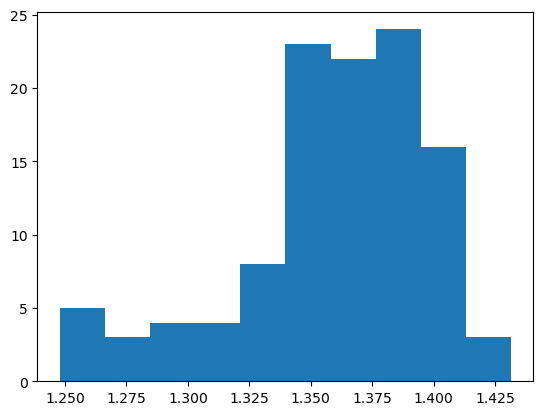

In [37]:
plt.hist(np.log10(np.array(tcga_samples.loc[tcga_samples.rail_id.isin(bc_normal_tissue)].errQ)))

In [7]:
lc_table = pd.read_csv('../code/results/tcga/ds/leafcutter1_files/leafcutter2_perind_numers.counts.gz', 
                       sep=' ', index_col=0)

In [8]:
(lc_table > 0).sum(axis=0)

Breast_Cancer.106628.junc    117689
Breast_Cancer.106636.junc    132947
Breast_Cancer.106645.junc    118106
Breast_Cancer.106653.junc    122964
Breast_Cancer.106684.junc     92416
                              ...  
Breast_Cancer.944367.junc    110710
Breast_Cancer.944370.junc    126410
Breast_Cancer.944372.junc    109667
Breast_Cancer.944483.junc    109743
Breast_Cancer.944490.junc     98869
Length: 1239, dtype: int64

In [15]:
normal_sample_names = [f'Breast_Cancer.{rail_id}.junc' for rail_id in bc_normal_tissue]
tumor_sample_names = [f'Breast_Cancer.{rail_id}.junc' for rail_id in bc_primary_tumor]

In [16]:
top_normal = (lc_table[normal_sample_names]> 0).sum(axis=0).sort_values()[-20:].index

In [17]:
top_tumor = (lc_table[tumor_sample_names]> 0).sum(axis=0).sort_values()[-20:].index

In [18]:
lc_table_slice = lc_table[list(top_normal) + list(top_tumor)]

In [21]:
lc_table_slice.loc[(lc_table_slice > 0).sum(axis=1) > 0].to_csv(
    '../code/results/tcga/ds/leafcutter1_files/leafcutter2_perind_numers.counts.filtered.gz', 
                       sep=' ', index=True, header=True)

In [22]:
ds_table = pd.read_csv('../code/results/tcga/ds/ds_sample_group.txt', sep='\t',
                       index_col = 0, names = ['condition', 'juncs', 'avleng', 'errQ'])

In [23]:
ds_table.loc[list(top_normal) + list(top_tumor)].to_csv(
    '../code/results/tcga/ds/ds_sample_group.filtered.txt', sep='\t',
    index=True, header=False
)

In [20]:
top_normal

Index(['Breast_Cancer.221453.junc', 'Breast_Cancer.428574.junc',
       'Breast_Cancer.26929.junc', 'Breast_Cancer.234812.junc',
       'Breast_Cancer.943526.junc', 'Breast_Cancer.439511.junc',
       'Breast_Cancer.110893.junc', 'Breast_Cancer.213352.junc',
       'Breast_Cancer.469620.junc', 'Breast_Cancer.110796.junc',
       'Breast_Cancer.117396.junc', 'Breast_Cancer.935526.junc',
       'Breast_Cancer.444982.junc', 'Breast_Cancer.865448.junc',
       'Breast_Cancer.219676.junc', 'Breast_Cancer.865828.junc',
       'Breast_Cancer.434939.junc', 'Breast_Cancer.467580.junc',
       'Breast_Cancer.853550.junc', 'Breast_Cancer.27820.junc'],
      dtype='object')